# Classifier Calibration

In [1]:
# Imports 
import pandas as pd
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.datasets import make_classification, make_blobs
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.calibration import CalibratedClassifierCV
from sklearn.calibration import CalibrationDisplay

## What if I told you that what you know about `predict_proba` is not the whole truth? 

Up until now, we have been treating the output of some classifiers that we have encountered, which have a `predict_proba` function, as **"the probability of belonging to class 1"** without really talking about what that means in more detail.

Q: Is it the case that if our classifier says that the probability of class 1 is, say 0.4, that we would expect to see 4 out out of 10 datapoints with those features to be positive? 

**Example:** in the case of the penguins, if we have a classification algorithm between Adelie and Gentoo based on flipper length and bodymass, if we have a penguin with flipper length 10 and body mass 4kg, and the model says p(Adelie) = 0.4, can we say that given 10 penguins with these measurements, 4 would be Adelie and 6 Gentoo? 

**Answer:** it turns out that the answer to the above is a bit more complicated than we have talked about so far!

### An example

Let's make some fake data!

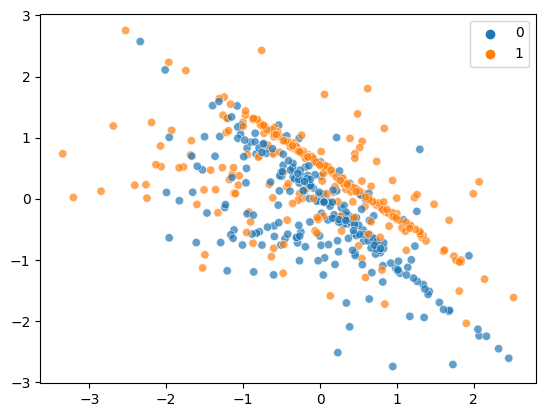

In [2]:
X_demo, y_demo = make_classification(n_classes=2, # how many classes we want - let's take 2 for simplicity
                                     n_features=2, n_informative=2, n_redundant=0, #we want 2 features and both are informative
                                     n_clusters_per_class=2, #you can play with this and set it to 1 as well
                                     n_samples=500, # how many samples - also feel free to change this
                                     class_sep=0.3, #how "messy" the separation is - the more the easier to separate
                                     random_state=99)

sns.scatterplot(x=X_demo[:,0], y=X_demo[:,1], hue=y_demo, alpha=0.7);

If we look at the above, we see that this is a tricky classification problem and that the classes are overlapping. This means that for certain values of our features, we are likely to find examples of both classes. This makes sense in the real world case, as it can be that e.g. a house that is at 2m above sea level and costs 500,000$ might be in New York or it might be in San Francisco. Or a car that has HP 500 and is green may be a BMW or it may be a Toyota. It is ok to have some uncertainty and some noise!


### How can we think about this uncertainty in terms of classification?

Let's say we train a Logistic Regression model on the above data. It will output us some `predict_proba` values, which is the value of the fitted logistic sigmoid function at a given input $x_1 ,x_2$:

In [3]:
logreg_model = LogisticRegression()
logreg_model.fit(X_demo,y_demo)
probs = logreg_model.predict_proba(X_demo)

Let's take a look at the output of `predict_proba` (just the first few lines):

In [4]:
probs[:10]

array([[0.4815875 , 0.5184125 ],
       [0.50930954, 0.49069046],
       [0.49810869, 0.50189131],
       [0.70685514, 0.29314486],
       [0.22681975, 0.77318025],
       [0.43854345, 0.56145655],
       [0.28152462, 0.71847538],
       [0.5947886 , 0.4052114 ],
       [0.29235609, 0.70764391],
       [0.83758407, 0.16241593]])

The first column is the "predicted probability" of belonging to class 0, and the second is the "predicted probability" of belonging to class 1. 

We want to take a closer look at what this "predicted probability" is and how it relates to reality so let's take this column and put it in a DataFrame with the true labels `y`:

In [5]:
class_1_proba = pd.Series(probs[:,1], # take the second column of our predict_proba output
                          name='predicted_proba_class_1'#call it something meaningful
                          )
df_pred_and_true= pd.concat([class_1_proba, pd.Series(y_demo, name='true_label')], axis=1) #add on our true labels

df_pred_and_true.head(10)

,predicted_proba_class_1,true_label
0,0.518412,0
1,0.490690,1
2,0.501891,1
3,0.293145,0
4,0.773180,0
5,0.561457,0
6,0.718475,1
7,0.405211,1
8,0.707644,1
9,0.162416,0


As you can see from the first few rows, we have a datapoint where the predicted probability was 0.77 and the true label was 0, one where the predicted probability was 0.71 and the true label was 1, and so on. 

So clearly, for the interval `(0.7,0.8]` in our predicted probabilities we also see some variation in the true labels. The question is, if the **average** predicted probability in that interval is, say, 0.75, would we **on average** see 3 out of 4 datapoints having a true label of 1? 

We can sort our new dataframe by predicted probability so it is easier to see:

In [6]:
df_pred_and_true.sort_values('predicted_proba_class_1', inplace=True)
df_pred_and_true.head(10)

,predicted_proba_class_1,true_label
267,0.055409,0
111,0.061750,0
475,0.094155,0
167,0.094831,0
204,0.105086,1
130,0.116420,0
407,0.133152,1
263,0.134177,0
95,0.139748,0
394,0.142552,0


As we can see, in the lower predicted probability brackets we still get some datapoints that belong to class 1. We want to see how often this happens, and it makes sense to take some averages over some intervals in the predicted probability. 
So we can check, 
- in the predicted probability interval `(0,0.1]` how many datapoints were actually class 1?
- in the interval `(0.1,0.2]` how many?
... and so on, and see how that relates to the probabilities we predicted.

We can use `pd.cut` to make some bins (=Intervals) in our data:


In [7]:
num_bins=10 # you can play around with this later
_, bins= pd.cut(np.linspace(0,1),num_bins, retbins=True) #creates the bins from the number given above
df_pred_and_true['probability_bin']= pd.cut(df_pred_and_true['predicted_proba_class_1'], bins=bins) #cuts our data
df_pred_and_true.head(28)

,predicted_proba_class_1,true_label,probability_bin
267,0.055409,0,"(-0.001, 0.1]"
111,0.061750,0,"(-0.001, 0.1]"
475,0.094155,0,"(-0.001, 0.1]"
167,0.094831,0,"(-0.001, 0.1]"
204,0.105086,1,"(0.1, 0.2]"
130,0.116420,0,"(0.1, 0.2]"
407,0.133152,1,"(0.1, 0.2]"
263,0.134177,0,"(0.1, 0.2]"
95,0.139748,0,"(0.1, 0.2]"
394,0.142552,0,"(0.1, 0.2]"


In the above, we can see that in the first bin, i.e. all the datapoints where we the predicted probability of being in class 1 was between 0 and 0.1, we have no datapoints where the true label was 1. If we assume that **on average** we could expect to see around 1 in 20 (so 0.05, i.e. halfway between 0 and 0.1, so the middle of this bin) datapoints be positive, does 4 out of 4 negative fit this assumption? ... we can't really say. 

What about the next bin?

There are 24 datapoints in it, with predicted probability between 0.1 and 0.2 - so if we take the middle of the bin as the expected probability in that bin, we would expect to see 0.15*24 = 3.6 datapoints that are actually positive. There are in fact 7 out of 24 which are positive, so 0.29 of the total number. How can we interpret this in relation to our `predict_proba`?

We could go on but we have 500 datapoints and many bins so let's use pandas to calculate the proportion of actual positives in each bin instead:

In [8]:
# First calculate mean probability per bin - rather than taking the midpoint
df_pred_and_true['mean_probability_per_bin']=df_pred_and_true.groupby("probability_bin", observed=False)['predicted_proba_class_1'].transform('mean')

# And now calculate what percentage of the datapoints in each bin was positive + return a dataframe
probs_vs_observed = df_pred_and_true.groupby('mean_probability_per_bin', observed=True)['true_label'].mean().to_frame()
# rename the column to be more sensible
probs_vs_observed.rename(columns={'true_label':'proportion_of_class_1_in_bin'}, inplace=True)

# Look at the result:
probs_vs_observed

,proportion_of_class_1_in_bin
mean_probability_per_bin,
0.076536,0.000000
0.159586,0.291667
0.257280,0.280702
0.348346,0.241379
0.453121,0.428571
0.555213,0.544554
0.649647,0.666667
0.735945,0.821429
0.841932,0.727273


So we can see above that in our case, there are some differences between the **average predicted probability for class 1 in each bin** and **how often we actually see class 1 in reality for that bin**. 

If `predict_proba` was a true reflection of the likelihood of belonging to class 1, then we would expect the numbers to be more or less equal, i.e. the predicted probability of belonging to class 1 should be more or less the same as the probability of encountering a datapoint of class 1 for those inputs!

We can plot this to visualise it further:

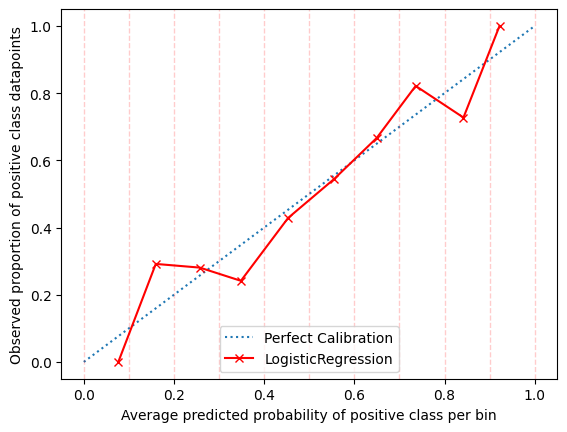

In [9]:
fig, ax = plt.subplots()
# Plot a line for the ideal case
ax.plot(np.linspace(0,1), np.linspace(0,1), linestyle="dotted", label="Perfect Calibration")
# Add some labels
ax.set_ylabel('Observed proportion of positive class datapoints')
ax.set_xlabel('Average predicted probability of positive class per bin')

ax.plot(probs_vs_observed, marker='x', label="LogisticRegression", color="red") 

# Show bin edges
plt.axvline(0, color='red', linestyle='--', linewidth=1, alpha=0.2)
for bin_bound in bins[1:]:
    plt.axvline(bin_bound, color='red', linestyle='--', linewidth=1, alpha=0.2)

# Add a legend
ax.legend();

In the above, the diagonal dotted line represents what we would expect to see our `predict_proba` always corresponded to the proportion of actual observed datapoints of class 1 in each bin. 

Instead, our classifier sometimes **underestimates** (=above the dotted line) and sometimes **overestimates** (=below the dotted line) how many positives there are. 

### The problem: different classifiers do this under- and overestimation in different ways!

This means that if we have two classifiers each giving us a predicted probability value for a datapoint that is the same, we cannot always take those outputs at face value. 

Worse still, if we are comparing them, we may need a different threshold for each. Or if we want to combine them in an Ensemble and take a soft vote, it can be that the voting isn't really "fair" if one of the models tends to be overly confident in its estimates, and does not correspond to reality as much. 

This is why we can **calibrate** our classifiers --> transform their outputs to be closer to the diagonal line in the plot above. 

### Let's compare some different classifiers

In [10]:
# Some helper functions: (doing what we did above but we want to repeat it --> make a function)

# Making the plot
def plot_predicted_vs_observed(*args, **kwargs):
    """This function helps us plot the calibration plot for classifier(s) passed in in the format 
    {"ClassifierName": dataframe of mean predicted probabilities and proportions of positive class per bin}
    
    Can also optionally pass in num_bins for plotting bin widths 
    - in case the classifiers have differing numbers of bins
    """
    # Instanciate the plot
    fig, ax = plt.subplots()
    ax.set_ylabel('Observed proportion of positive class datapoints')
    ax.set_xlabel('Average predicted probability of positive class per bin')
    
    # Make a plot of the ideal case scenario
    ax.plot(np.linspace(0,1), np.linspace(0,1), linestyle="dotted", label="Perfect Calibration")
    
    # This means we can call this function for a single classifier as well as several
    for arg in args:
        for k, v in arg.items():
            #Our input(s) is/are of the form {'ClassifierName':some_dataframe}
            # so k = ClassifierName and this goes in the legend
            # v= the dataframe we are trying to plot
            ax.plot(v, marker='x', label=k)
            # We get the number of bins to plot the boundaries from the dataframe which has the same length 
            num_bins=len(v)  
    
    #Now we plot some vertical lines to mark the edges of the bins:
    if 'num_bins' in kwargs.keys(): #this means we can optionally pass this number in when calling the function
        num_bins = kwargs['num_bins']
    xx = pd.cut(np.linspace(0,1),num_bins).unique().to_numpy()
    plt.axvline(0, color='red', linestyle='--', linewidth=1, alpha=0.2)
    for bin_bounds in xx:
        plt.axvline(bin_bounds.right, color='red', linestyle='--', linewidth=1, alpha=0.2)
    
    #Add a legend
    ax.legend();

# Getting the dataframe of proportion of positives, with a plotting option if we want it
def get_positive_class_proportions(clf, X, y, num_bins=10, plot=False,fit_clf=True, **kwargs):
    """This function takes as input:
        - clf --> a instanciated (but not yet fit) classifier with predict_proba method
        - X, y --> data and labels (2D and 1D array or DataFrame/Series respectively)
        - num_bins --> how many bins we want to split the predicted probabilities into
            --> these will be equally spaced intervals between 0 and 1, so for 10 it will be [0,0.1], (0.1,0.2], (0.2,0.3] etc
        - plot --> Boolean, 
            --> if False then this function returns only the dataframe of mean probability per bin
            --> if True, it  returns same DataFrame but also plots the predicted probabilities vs real proportion of class 1 datapoints per bin.
    """
    # First we optionally fit the classifier to our data and get out the predicted probabilities for class 1
    if fit_clf:
        clf.fit(X,y)
    
    probs = clf.predict_proba(X)
    class_1_proba = pd.Series(probs[:,1], name='predicted_proba_class_1')

    # Make a DataFrame from this and the true target class labels for each data point
    df_hat_true= pd.concat([class_1_proba, pd.Series(y, name='true_label')], axis=1)
    df_hat_true.sort_values('predicted_proba_class_1', inplace=True)

    #Make some bins (number specified as input) and split the predicted probabilities into these bins
    _, bins= pd.cut(np.linspace(0,1),num_bins, retbins=True)
    df_hat_true['probability_bin']= pd.cut(df_hat_true['predicted_proba_class_1'], bins=bins)
    
    #Calculate the mean predicted probability per bin
    df_hat_true['mean_probability_per_bin']=df_hat_true.groupby("probability_bin", observed=False)['predicted_proba_class_1'].transform('mean')
    
    # For each bin (now represented by the mean predicted probability) calculate what proportion of datapoints belongs to class 1:
    probs_vs_observed = df_hat_true.groupby('mean_probability_per_bin', observed=True)['true_label'].mean()

    # Return this as a dictionary of {Classifier Name : dataframe of results of the above}
    if "get_name" in kwargs.keys():
        # this is in case we need to get the name of the underlying estimator
        if kwargs["get_name"]== True:
            probability_vs_observed_dict = {type(clf.estimator).__name__: probs_vs_observed.to_frame()}
    else:
        probability_vs_observed_dict = {type(clf).__name__: probs_vs_observed.to_frame()}

    if plot==True:
        #plot the classifier as in the function defined above and return the dictionary
        plot_predicted_vs_observed(probability_vs_observed_dict)
        return probability_vs_observed_dict
    else:
        # only return the dictionary
        return probability_vs_observed_dict

### Now let's make some new fake data and try comparing different classifiers to each other

We will use `make classification` again but this time with more features, so that we cannot visualise it like last time. We are still focussing on the binary classification case for this example.

In [11]:
X, y = make_classification(n_samples=1000, n_classes=2, 
                           n_features=50, n_clusters_per_class=5, n_informative=40, n_redundant=8, 
                           class_sep=0.3, random_state=2)

Now let's instanciate a few different classifiers that all have a `predict_proba` method. By the way, if you want to see all of the available ones with this option, try running this code:

```
from sklearn.utils import all_estimators
estimators = all_estimators()
for name, class_ in estimators:
    if hasattr(class_, 'predict_proba'):
        print(name)
```

In [12]:
# We will try these 4, but feel free to try it with any others you know.
# First we just instanciate them, with or without some hyperparameters:
logreg = LogisticRegression()
rfc = RandomForestClassifier(n_estimators=50, max_depth=3)
svc = SVC(probability=True, C=1.5)
knn= KNeighborsClassifier(n_neighbors=3)


In [13]:
# Now we call the above function, which fits the classifier and returns a dataframe of the result.
knn_uncalibrated = get_positive_class_proportions(knn, X, y)
svc_uncalibrated=get_positive_class_proportions(svc, X, y)
logreg_uncalibrated = get_positive_class_proportions(logreg, X,y)
rfc_uncalibrated=get_positive_class_proportions(rfc, X, y)

Now we can compare the classifiers by plotting them all together:

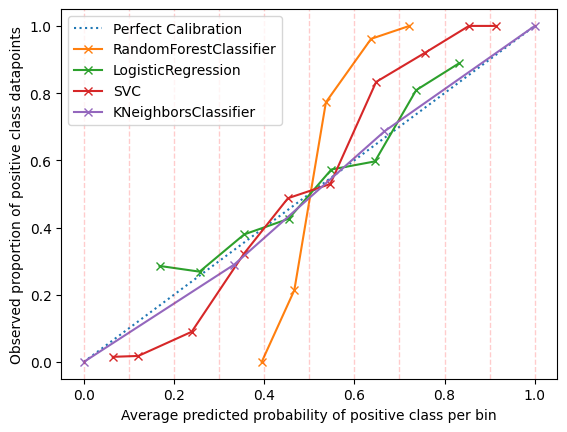

In [14]:
plot_predicted_vs_observed(rfc_uncalibrated, logreg_uncalibrated, svc_uncalibrated, knn_uncalibrated, num_bins=10)

As we can see, the classifiers all perform pretty differently on the same data in terms of how they over- and underestimate the proportions of actual positive class datapoints. 
- So a `predict_proba` of around 0.45 from logistic regression corresponds to around 45% of the data actually belonging to class 1 - cool!
- At the same time, if our Random Forest gives us an output of 0.45, actually only around 20% of the data was really positive. So the Random forest is overestimating a lot. 

At the other extreme:
- if our random forest says that `predict_proba` for a datapoint is around 0.6, it is underestimating by a lot as the proportion of actual class 1 datapoints is almost 100%
- LogisticRegression and especially KNN on the other hand are pretty spot-on in this case.


#### What is the problem with this?

If we are to make statements about our model such as:
- "a customer fitting this description is 70% likely to churn, we should send them a special offer to encourage them to stay"
- "a transaction with these features is only 60% likely to be fraudulent, that's below our threshold of 70%, let's not flag it"

...we are making real-world statements of probability that may not reflect the actual facts. It can be that we used an overly confident model and the customer is only 40% likely to churn, or the model is being too cautious and actually more than 60% of transactions that fit a particular profile are fraud.


The other issue is if we use a VotingClassifier and take a soft vote -> an overly confident (and overestimating) model will get a higher vote in the ensemble and may skew the overall output.

#### What is the answer? 

`sklearn` has a CalibratedClassifierCV class that can address this issue, or **calibrate** our classifier. 
The way it works:
- we need a dataset to train a model and a separate one to calibrate it (to prevent overfitting)
    - we can use a pre-trained model with a new dataset
    - or we can train an untrained model with a whole dataset and using CrossValidation under the hood we make sure the data used for training and calibrating is kept separate

In [ ]:
# Make more data, different random state though
X_val, y_val = make_classification(n_samples=1000, n_classes=2, 
                           n_features=50, n_clusters_per_class=5, n_informative=40, n_redundant=8, 
                           class_sep=0.3, random_state=3)

In [16]:
calibrated_logreg = CalibratedClassifierCV(logreg, method='isotonic',cv="prefit")
calibrated_rfc = CalibratedClassifierCV(rfc,method='isotonic',cv="prefit")
calibrated_svc = CalibratedClassifierCV(svc,method='isotonic', cv="prefit")
calibrated_knn = CalibratedClassifierCV(knn, method='isotonic',cv="prefit")

In [17]:
knn_calibrated = get_positive_class_proportions(calibrated_knn, X_val, y_val, get_name=True)
svc_calibrated=get_positive_class_proportions(calibrated_svc, X_val, y_val, get_name=True)
logreg_calibrated = get_positive_class_proportions(calibrated_logreg, X_val, y_val, get_name=True)
rfc_calibrated=get_positive_class_proportions(calibrated_rfc, X_val, y_val, get_name=True)


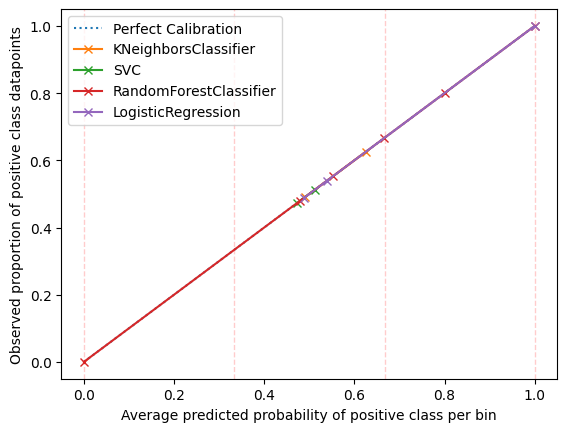

In [18]:
plot_predicted_vs_observed(knn_calibrated, svc_calibrated,rfc_calibrated, logreg_calibrated )

Now if we use the calibrated versions of our models, we can ensemble them and take a soft vote or use them in stacking/blending models and be sure that none of them are over-or underestimating like they were before!

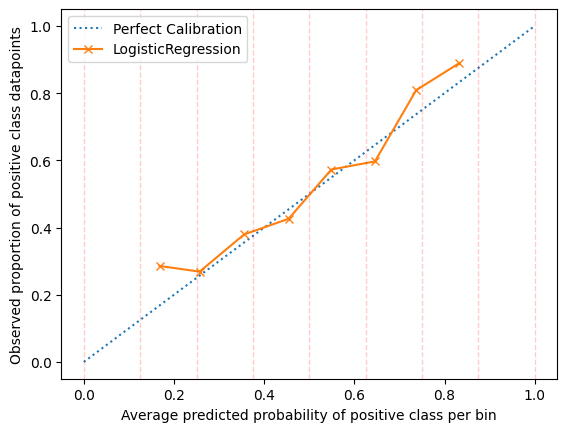

In [19]:
plot_predicted_vs_observed(logreg_uncalibrated)

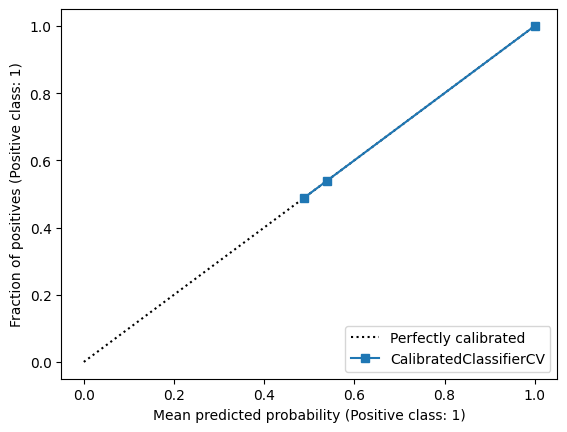